### Simulation Results

In [1]:
import numpy as np, pandas as pd
import importlib
import test_WTM as wtm
import gudhi_persistence as gp
import utilsA1 as utils
import os, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from lifelines import CoxTimeVaryingFitter


In [2]:
importlib.reload(wtm)
importlib.reload(utils)
importlib.reload(gp)

PATH = os.getcwd()
output_file = "FLCRM"
params_temp_list = {'num_nodes': 60, 'num_neighbor_nodes': 1,
                    'total_random_edges': 3, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 1, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations', 'calculate_representation': True,
                    'bandwidth': 0.1, 'num_landscapes': 3, 'resolution': 50}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) - 200

df, activation_results = wtm.main_sims(params_list=[params_temp_list],
                   output_file=output_file, save_files=False)

In [4]:
df.head(10)

,simulation_id,realization_id,num_nodes,time,state,state_abnormal_sum,num_active_nodes,active_nodes,node_active_threshold,H0,...,distance_threshold,L_0,L_1,L_2,I_0,I_1,I_2,E_0,E_1,E_2
0,0,0,60,0,0,1570,1,"[0.0, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
1,0,0,60,1,0,1570,6,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...",0.01,4,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
2,0,0,60,2,0,1570,23,"[0.0, 1.0, 2.0, nan, nan, nan, nan, 2.0, 2.0, ...",0.01,9,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
3,0,0,60,3,0,1570,52,"[0.0, 1.0, 2.0, 3.0, nan, 3.0, 3.0, 2.0, 2.0, ...",0.01,8,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
4,0,0,60,4,1,1570,60,"[0.0, 1.0, 2.0, 3.0, 4.0, 3.0, 3.0, 2.0, 2.0, ...",0.01,1,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[2.3876161144351616e-08, 6.487510905068569e-08...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",8,0,0
5,0,1,60,0,0,1570,1,"[nan, 0.0, nan, nan, nan, nan, nan, nan, nan, ...",0.01,1,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
6,0,1,60,1,0,1570,6,"[1.0, 0.0, 1.0, nan, nan, nan, nan, nan, nan, ...",0.01,4,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
7,0,1,60,2,0,1570,25,"[1.0, 0.0, 1.0, 2.0, nan, 2.0, nan, nan, 2.0, ...",0.01,13,...,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,0,0
8,0,1,60,3,1,1570,58,"[1.0, 0.0, 1.0, 2.0, 3.0, 2.0, 3.0, 3.0, 2.0, ...",0.01,2,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.1072798038868416e-16, 1.0844595194242545e-1...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",5,0,0
9,0,1,60,4,1,1570,60,"[1.0, 0.0, 1.0, 2.0, 3.0, 2.0, 3.0, 3.0, 2.0, ...",0.01,1,...,2,"[0.02495670992423108, 0.04991341984846216, 0.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

#### Homology Representation

In [28]:

importlib.reload(gp)
importlib.reload(wtm)

params_temp_list['seeding_method'] = 'cluster_seeding'
G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
graph, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=graph, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))
betti_numbers, persistence, persistence_intervals_for_diagram = gp.compute_persistence(graph=graph, activation_times=activation_times, max_dim=2)
print(f"Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/{output_file}.html")


Graphs @: file:///C:/Users/sranasin/Desktop/NetworkModels/Project1/A1/Outputs/FLCRM.html


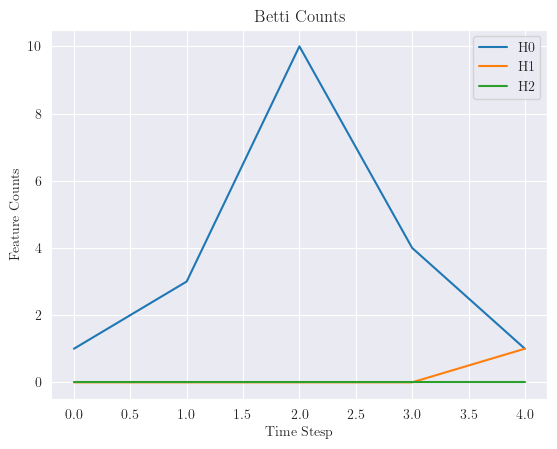

In [31]:
gp.betti_nums_over_time(betti_over_time=betti_numbers)

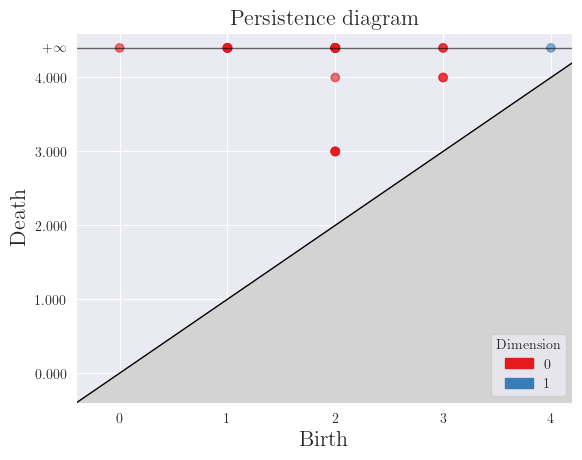

In [29]:
gp.persistence_diagram(persistence_intervals_for_diagram)

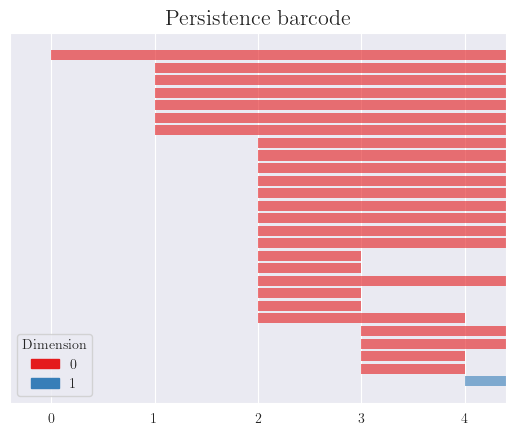

In [30]:
gp.persistence_barcodes(persistence_intervals_for_diagram)

#### Persistence Images / Landscapes

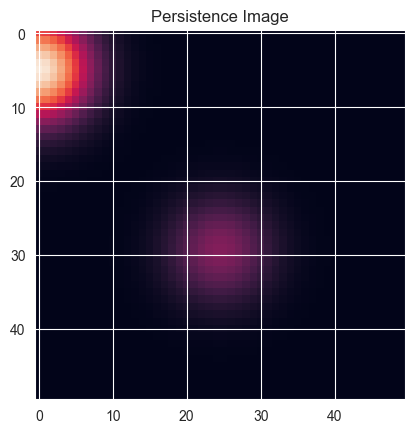

In [5]:
row_id = 4
resolution = params_temp_list['resolution']
plt.imshow(np.flip(np.reshape(df.loc[row_id, 'I_0'], [resolution,resolution]), 0))
plt.title("Persistence Image")
plt.show()

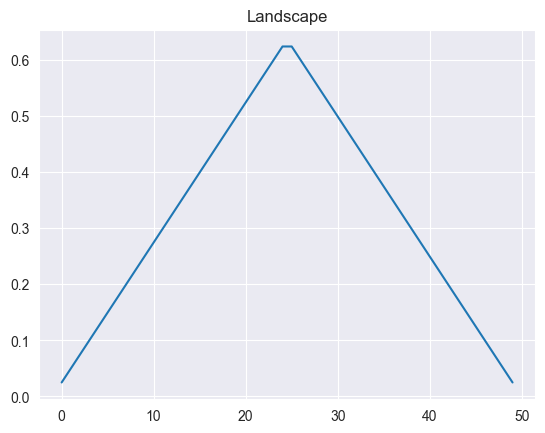

In [6]:
plt.plot(df.loc[row_id, 'L_0'][:resolution])
plt.plot(df.loc[row_id, 'L_1'][resolution: resolution*2])
plt.plot(df.loc[row_id, 'L_2'][resolution*2:resolution*3])
plt.title("Landscape")
plt.show()

In [19]:
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 3

df_pca = df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['simulation_id', 'realization_id', 'time', 'state', 'E_0', 'E_1', 'E_2'], how='left')


In [20]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.65504152 0.85304431 0.91924539]
Skipping L_1 — no valid data.
Skipping L_2 — no valid data.
Explained variance ratio: [0.52500759 0.81940809 0.95329658]
Skipping I_1 — no valid data.
Skipping I_2 — no valid data.


In [21]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["simulation_id", "realization_id", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["simulation_id", "realization_id"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state"] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['simulation_id'].astype(str) + df['realization_id'].astype(str) + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_11140\4236309303.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,L_0_PC1,L_0_PC2,L_0_PC3,I_0_PC1,I_0_PC2,I_0_PC3,E_0,E_1,E_2
0,000,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
1,001,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
2,002,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
3,003,3,4.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
4,004,4,5.0,1,1.765641,0.736116,-0.192475,182.161331,99.054118,-101.269190,8,0,0
5,010,0,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
6,011,1,2.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
7,012,2,3.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0
8,013,3,4.0,1,1.765641,0.736116,-0.192475,112.128857,-32.302668,14.638953,5,0,0
9,014,4,5.0,1,-0.997816,0.544378,0.882112,-97.999363,32.549417,98.518810,5,0,0


### Time-Varying FLCRM

In [23]:
df_pca.drop(columns = ['E_1', 'E_2'], inplace=True)

ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 300 periods, 300 subjects, 87 events>
         event col = 'state'
number of subjects = 300
 number of periods = 300
  number of events = 87
partial log-likelihood = -291.69
  time fit was run = 2025-08-11 08:48:10 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
L_0_PC1    0.07      1.08      0.28           -0.48            0.63                0.62                1.88
L_0_PC2    0.03      1.03      0.18           -0.32            0.38                0.72                1.47
L_0_PC3    0.13      1.14      0.43           -0.71            0.98                0.49                2.65
I_0_PC1    0.00      1.00      0.00           -0.01            0.01                0.99                1.01
I_0_PC2   -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
I_0_PC3   -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
E_0        0.03      1.03      0.06           -0.09            0.14                0.92                1.15

           cmp to     z    p  -log2(p)
covariate                             
L_0_PC1      0.00  0.26 0.80      0.32
L_0_PC2      0.00  0.17 0.87      0.21
L_0_PC3      0.00  0.31 0.76      0.40
I_0_PC1      0.00  0.08 0.94      0.10
I_0_PC2      0.00 -0.53 0.60      0.74
I_0_PC3      0.00 -0.03 0.98      0.03
E_0          0.00  0.49 0.63      0.68
---
Partial AIC = 597.37
log-likelihood ratio test = 1.03 on 7 df
-log2(p) of ll-ratio test = 0.01

<Axes: xlabel='log(HR) (95% CI)'>

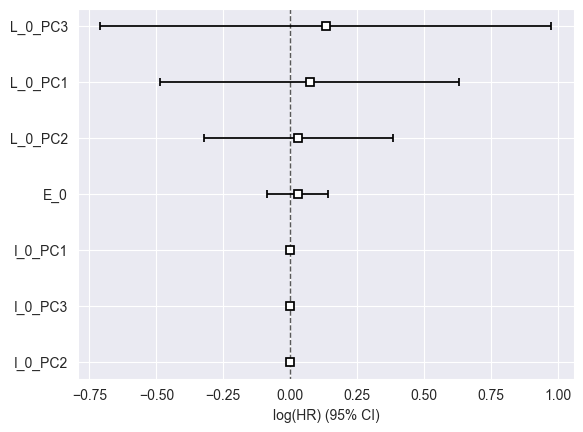

In [25]:
ctv.plot()
